In [1]:
import pandas as pd
import numpy as np

import tubesml as tml


import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

from source.report import report_points, report_victory, _point_to_proba


from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge, LogisticRegression, Lasso
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb

In [2]:
def train_predict(data, test_data, target, estimator, cv, test_target=None, fit_params=None, early_stopping=False, shap=True, result_compare=None):
    cv_score = tml.CrossValidate(data=data, target=target, test=test_data,
                                 estimator=estimator, cv=cv, fit_params=fit_params, early_stopping=early_stopping,
                                shap=shap, imp_coef=True, predict_proba=True, regression=False)

    oof, pred, result_dict = cv_score.score()

    score = brier_score_loss(y_true=target, y_prob=oof)
    print(f"OOF score: {score}")

    if early_stopping:
        print(result_dict["iterations"])

    if shap:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="both", n=10)
        to_plot = result_dict["feat_imp"].head(10)["Feature"].to_list()
        tml.plot_shap_values(result_dict["shap_values"], features=to_plot)
    else:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="standard", n=10)

    tml.eval_classification(data=data, target=target, preds=oof,
                        proba=True, thrs=0.5, plot=True, feat="delta_Seed")

    if result_compare is not None:
        baseline = result_compare["score"]
        ref_oof = result_compare["oof"]

        if score - baseline >= 0:
            print(f"This is {round((score - baseline) / baseline * 100, 3)}% worse than the baseline.")
        else:
            print(f"This is {round(-(score - baseline) / baseline * 100, 3)}% better than the baseline.")
    
        comparison = tml.CompareModels(data=data, true_label=target.reset_index(drop=True),
                                       pred_1=oof, pred_2=ref_oof,
                                       kfold=cv,
                                       regression=True,
                                       probabilities=True,
                                       metric_func=mean_squared_error)
    
        comparison.compare_metrics()
        comparison.compare_predictions()
        comparison.statistical_significance()

    if test_target is not None:
        score = brier_score_loss(y_true=test_target, y_prob=pred)
        print(f"Test score: {score}")
        tml.eval_classification(data=data, target=target, preds=oof,
                        proba=True, thrs=0.5, plot=True, feat="delta_Seed")

    return oof, pred, result_dict

In [3]:
df = pd.read_csv("data/processed/men_training.csv")

DROP = ["target", "target_points", "ID", "DayNum", "Team1", "Team2",
        'T1_Loc', 'T2_Loc',
                "T1_region", "T2_region", "Season", "delta_Loc",
                "Season", "competitive", "competitive_score",
                "delta_def_rating_diff", "delta_impact_diff",
                "T1_def_rating_diff", "T2_def_rating_diff"]


N_FOLDS = 5
kfolds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=13)

df_train, df_test = tml.make_test(df, test_size=0.2, random_state=34)

In [12]:
result_dict["feat_imp"].head(20)

,Feature,shap_importance,shap_std,mean,std
0,delta_FGA3_diff,0.722021,0.009247,-0.890804,0.028813
1,delta_FG3_ratio_diff,0.720175,0.009619,0.899450,0.063038
2,delta_Opp_True_shooting_perc,0.562529,0.007480,0.706839,0.043612
3,delta_impact,0.523861,0.007487,0.672811,0.072434
4,delta_FGM3_perc,0.485630,0.006421,-0.607755,0.035518
5,delta_FGA2_diff,0.483142,0.006364,0.596251,0.035028
6,delta_FG3_ratio,0.460131,0.006323,-0.577441,0.046317
7,T2_Opp_True_shooting_perc,0.421506,0.005548,-0.522269,0.026870
8,delta_Blk,0.371241,0.005239,0.484453,0.033471
9,T1_Opp_True_shooting_perc,0.370337,0.005020,0.476426,0.037420


OOF score: 0.1833801118159031


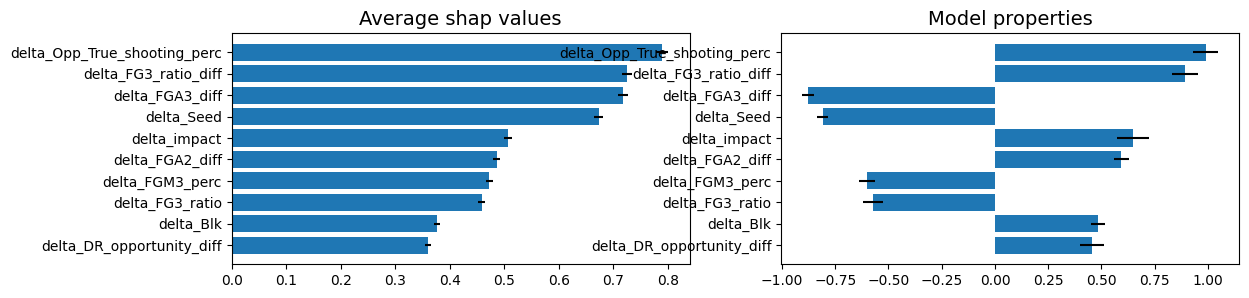

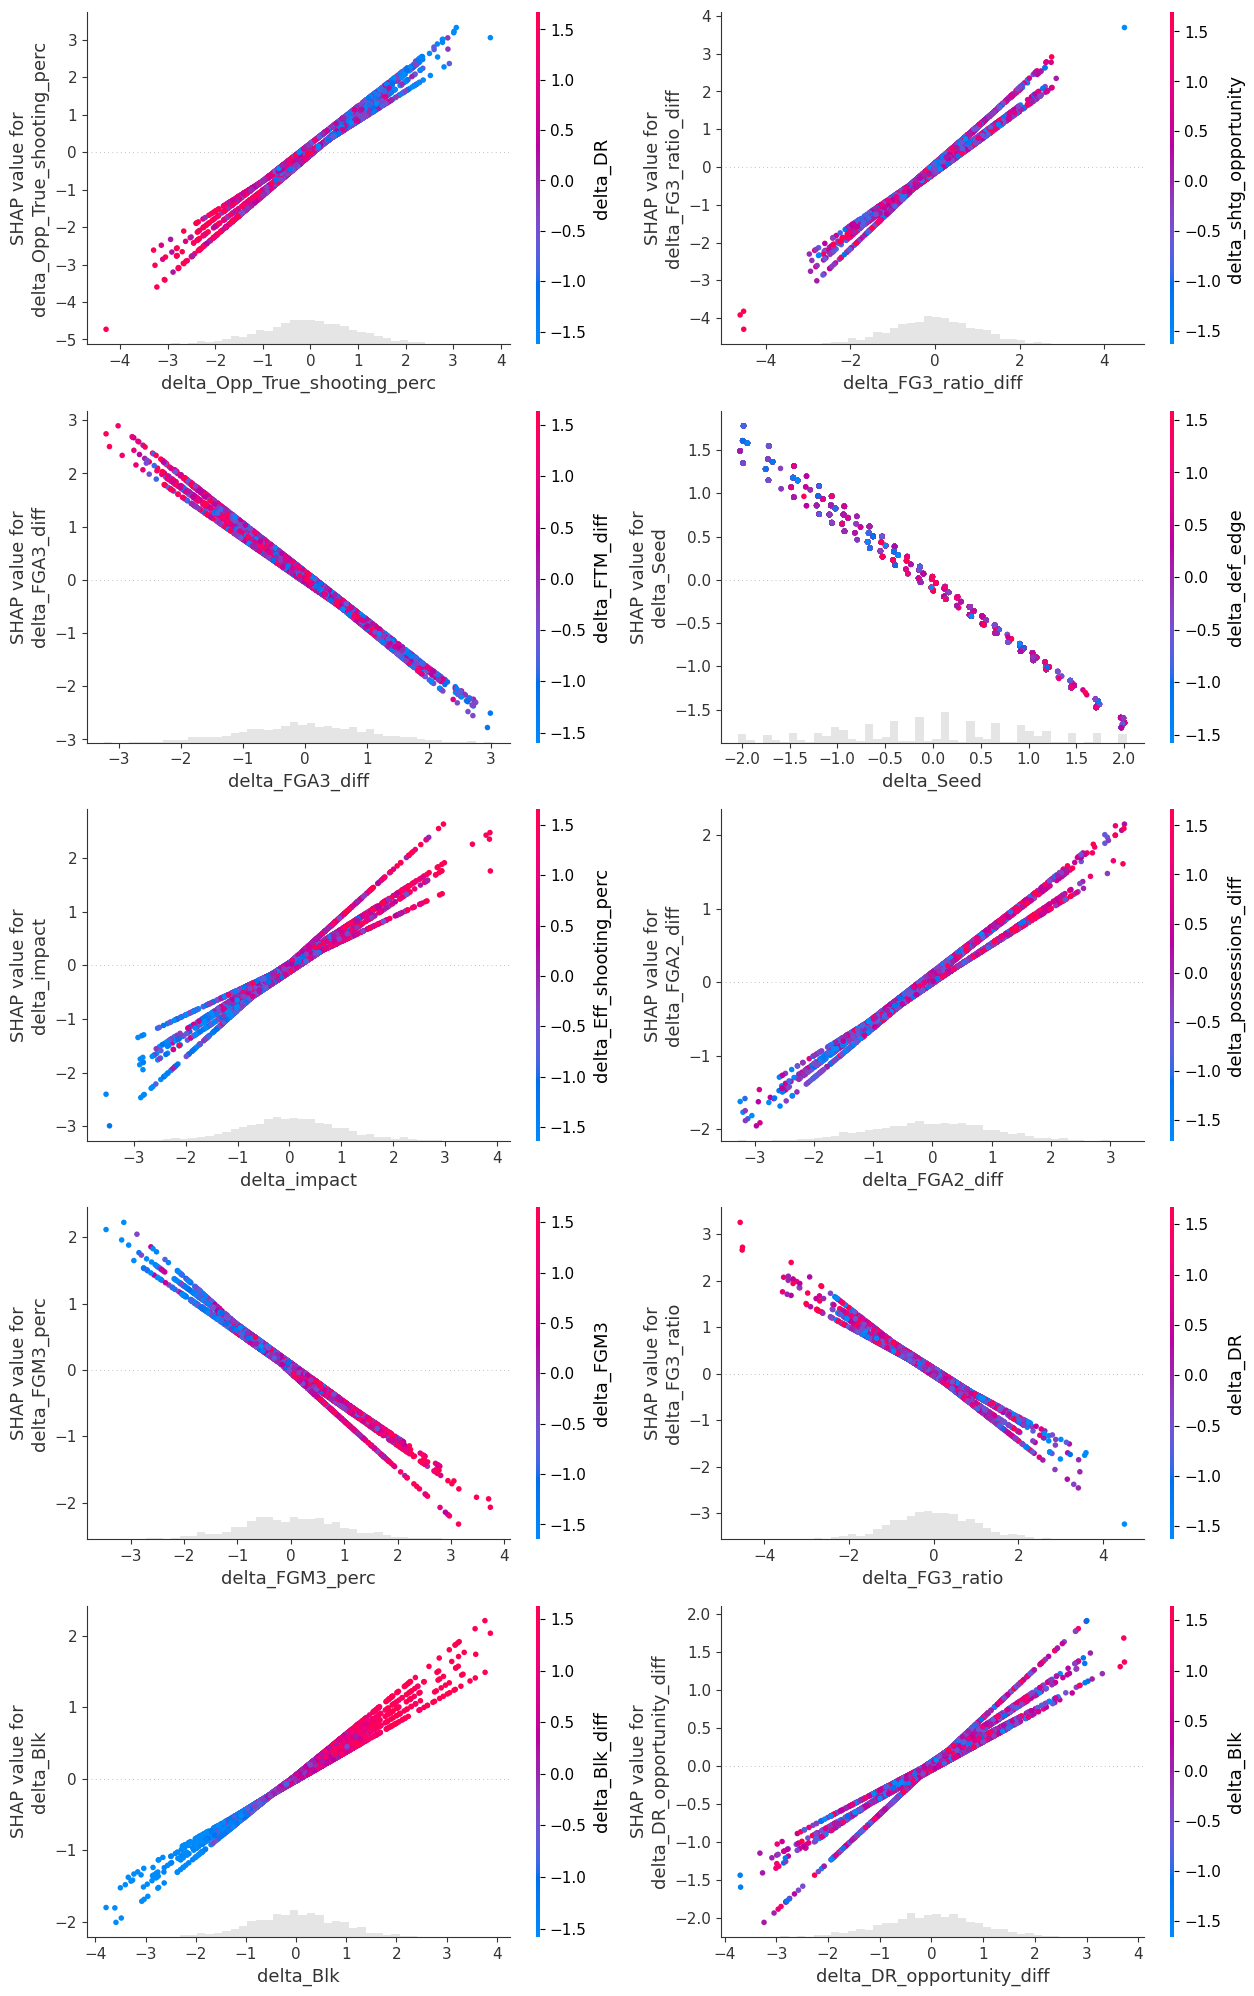

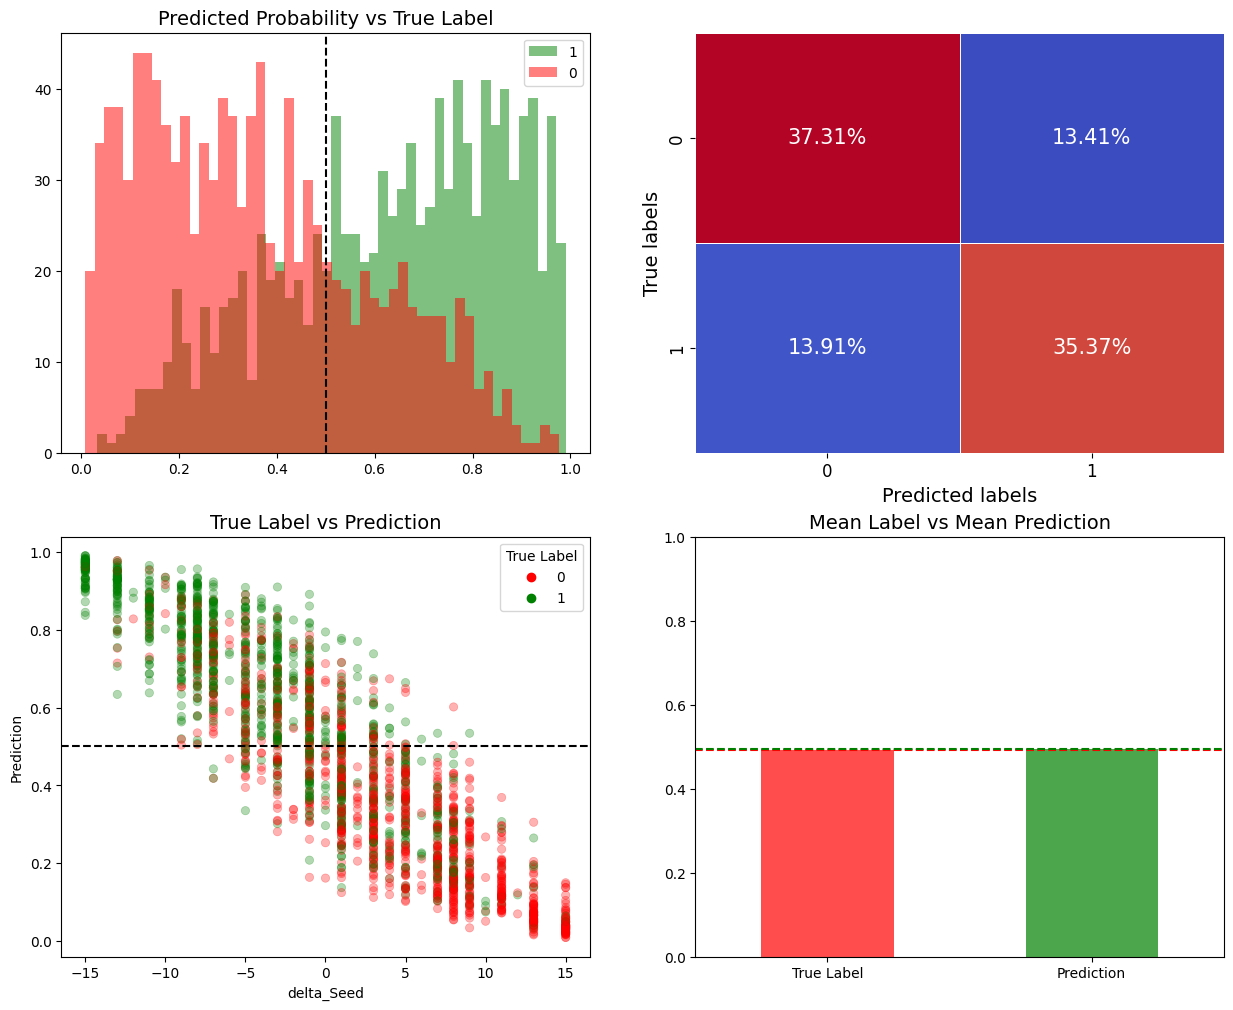

Accuracy score: 	0.7268
AUC ROC: 		0.7981
              precision    recall  f1-score   support

           0       0.73      0.74      0.73      1127
           1       0.73      0.72      0.72      1095

    accuracy                           0.73      2222
   macro avg       0.73      0.73      0.73      2222
weighted avg       0.73      0.73      0.73      2222

Test score: 0.18063826335985164


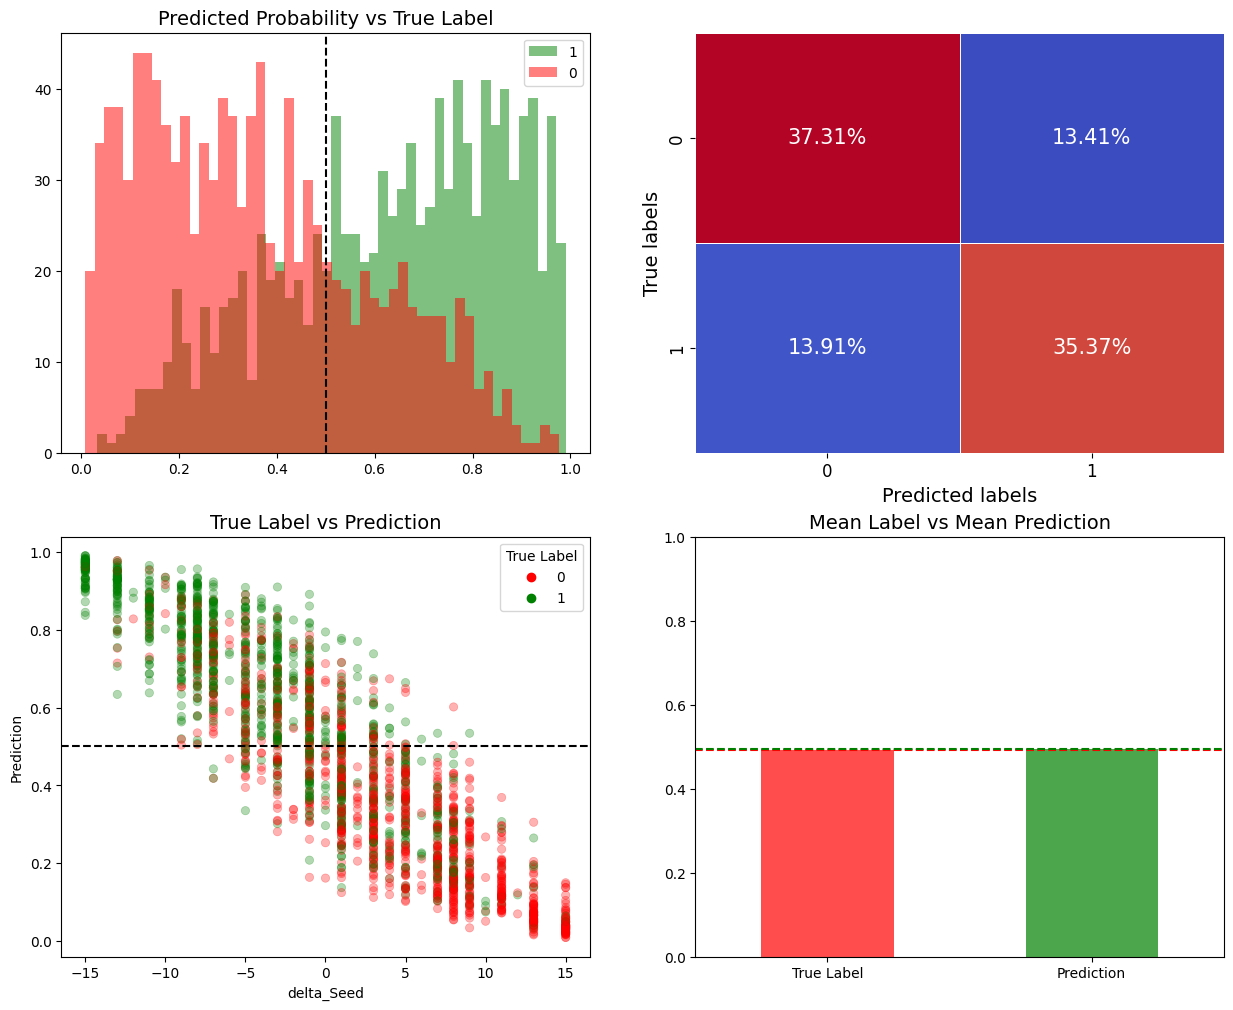

Accuracy score: 	0.7268
AUC ROC: 		0.7981
              precision    recall  f1-score   support

           0       0.73      0.74      0.73      1127
           1       0.73      0.72      0.72      1095

    accuracy                           0.73      2222
   macro avg       0.73      0.73      0.73      2222
weighted avg       0.73      0.73      0.73      2222

Accuracy train: 		 0.7268
Accuracy test: 			 0.7212
Logloss train: 			 0.5419
Logloss test: 			 0.5358
Brier train: 			 0.1834
Brier test: 			 0.1806
Unsure train: 			 20.8371%
Unsure test: 			 20.5036%


,acc_oof,acc_test,logloss_oof,logloss_test,unsure_oof,unsure_test,brier_oof,brier_test
0,0.7268,0.7212,0.5419,0.5358,20.8371,20.5036,0.1834,0.1806


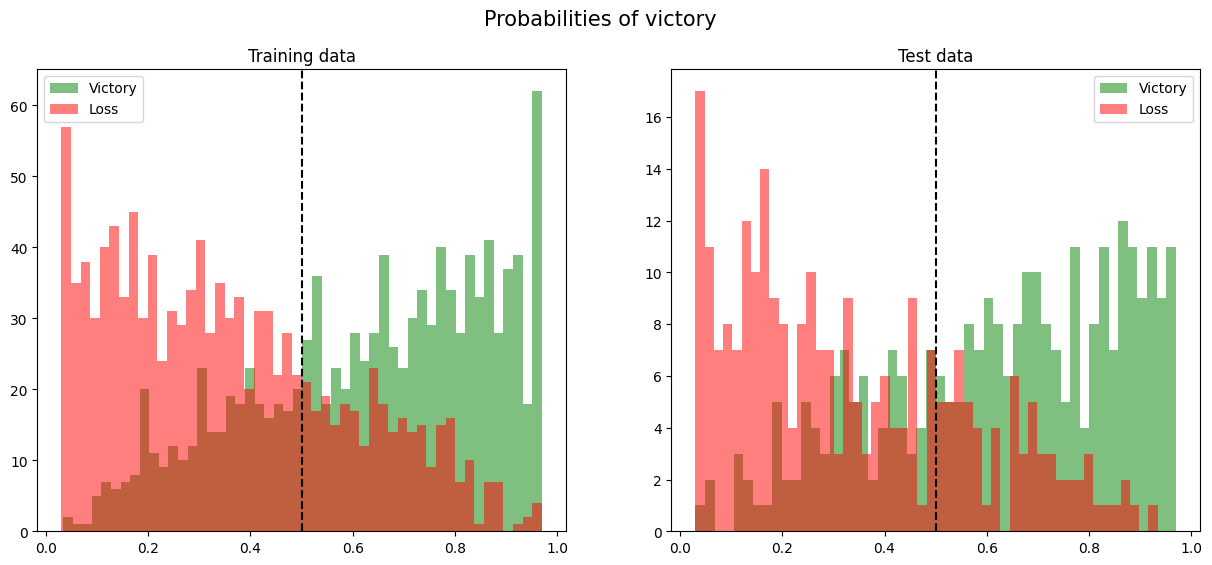

In [19]:
target = df_train["target"]

not_imp = [
 'delta_True_shooting_perc',
 'delta_opp_FTA',
 'delta_off_edge',
 'delta_FGM2_diff',
 'delta_Tot_Reb',
 'delta_possessions',
 'delta_opp_possessions',
 'delta_Ast_TO_ratio_diff',
 'delta_Ast_TO_ratio',
 'delta_quality']

extras = ["T1_Opp_True_shooting_perc", "T2_Opp_True_shooting_perc",
          #"T1_Seed", "T2_Seed",
          #"T1_impact", "T2_impact", "T1_FGM3_perc", "T2_FGM3_perc"
          ]
FEATURES = [c for c in df_train if "delta" in c and c not in DROP and c not in not_imp] #+ extras
train = df_train[FEATURES].copy()
test_target = df_test["target"]
test = df_test[FEATURES].copy()

model = LogisticRegression(C=0.67, random_state=34, max_iter=10000, n_jobs=-1)

pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", model)])

oof, pred, result_dict = train_predict(data=train, test_data=test, target=target,
                                       estimator=pipe, cv=kfolds, test_target=test_target,
                                       fit_params=None, early_stopping=False,
                                       shap=True, result_compare=None)


report_victory(y_train=target, y_test=test_target, oof=oof, preds=pred)

In [20]:
df_train["oof_prob"] = oof
df_test["pred_prob"] = pred

df_train["sqr_err_prob"] = (df_train["target"] - df_train["oof_prob"])**2
df_test["sqr_err_prob"] = (df_test["target"] - df_test["pred_prob"])**2

In [21]:
df_train.groupby("stage_Round1")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_Round1,
False,0.202470
True,0.164799


In [22]:
df_train.groupby("stage_Round2")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_Round2,
False,0.183754
True,0.182279


In [23]:
df_train.groupby("stage_Round3")[[ "sqr_err_prob"]].mean()

,sqr_err_prob
stage_Round3,
False,0.179461
True,0.210565


In [24]:
df_train.groupby("stage_Round4")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_Round4,
False,0.177871
True,0.265933


In [25]:
df_train.groupby("stage_finalfour")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_finalfour,
False,0.182058
True,0.221766


In [26]:
df_train.groupby("stage_final")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_final,
False,0.183539
True,0.173144


In [29]:
thrs = np.arange(0, 25)

for th in thrs:
    tmp = df_train.copy()
    tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + th / 100) & (tmp["stage_Round3"]), "oof_prob"] = 0.5 + th / 100
    tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - th / 100) & (tmp["stage_Round3"]), "oof_prob"] = 0.5 - th / 100
    tmp["sqr_err_prob"] = (tmp["target"] - tmp["oof_prob"])**2

    print(th, tmp["sqr_err_prob"].mean())

0 0.1833801118159031
1 0.18338884859501636
2 0.18339152853927115
3 0.18337936501782115
4 0.18335183371997696
5 0.1833273641597766
6 0.18328950075467468
7 0.18324078594134588
8 0.18318699254849433
9 0.18313175850477828
10 0.18307160083002616
11 0.18301844952588822
12 0.18297073301645175
13 0.18293780463626808
14 0.18292518643693906
15 0.1829326390276765
16 0.18295204375833676
17 0.1829808867708126
18 0.18302752074039882
19 0.18311153200486624
20 0.18321616606298646
21 0.1833432704277024
22 0.18348534289508983
23 0.18364660588980067
24 0.1838322372155473


Round 2 12
 

In [30]:
df_train.to_csv("data/results/men_train_logit.csv", index=False)
df_test.to_csv("data/results/men_test_logit.csv", index=False)